# Student Performance Data Explorer

**AI & ML Internship - Task 1:** Development Environment Setup, Python Foundations & Data Exploration

This notebook is an Exploratory Data Analysis (EDA) of a student exam-score dataset. It follows a
simple workflow: **load -> inspect -> check quality -> clean -> describe -> visualize -> interpret**.

**Contents**

1. Introduction
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Data Quality Analysis
6. Data Cleaning
7. Descriptive Statistics
8. Univariate Analysis
9. Bivariate Analysis
10. Correlation Analysis
11. Outlier Analysis
12. Comparative Analysis
13. Key Insights
14. Preparing for Task 2
15. Conclusion

## 1. Introduction

### Project objective
The objective of this project is to explore and understand a student performance dataset using
Python, Pandas and data-visualization libraries. The work covers loading the data, checking its
structure and quality, cleaning it, calculating descriptive statistics, studying correlations,
detecting potential outliers and writing down what the data actually shows.

> **Scope note:** this is Task 1 (data exploration). No machine-learning model is built here.

### Why analyze student performance data?
Exam scores are a common, easy-to-measure indicator of how students are doing. Looking at how scores
are distributed, and how they differ across groups, is a typical first step before any deeper
educational or predictive work. For an EDA exercise the dataset is also a good fit because it mixes
**numerical** columns (scores) with **categorical** columns (student background).

### Questions this analysis tries to answer
1. What does the dataset contain, and is its quality good enough for analysis?
2. How are the math, reading and writing scores distributed (centre, spread, shape)?
3. How strongly are the three scores related to each other?
4. Are there unusually low or high scores, and do they look like real performance or like data errors?
5. How do average scores differ across gender, race/ethnicity, parental education, lunch type and
   test-preparation status?

### About the data
The dataset is the public **"Students Performance in Exams"** dataset (1,000 students, 8 columns;
see `data/README.md` for details). Its Kaggle page does not document how the data was collected, so
the results below describe **this dataset only** and should not be generalized to real student
populations. Also, a relationship found in the data (a *correlation* or a *group difference*) does
**not** prove that one variable *causes* the other.

## 2. Import Libraries

Only four libraries are needed: **pandas** (tables), **numpy** (numeric helpers), **matplotlib**
and **seaborn** (charts). The reusable helper functions written for this project live in the `src/`
folder (`data_cleaning.py` and `data_analysis.py`), so the notebook stays short and readable.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Where is the dataset? The notebook lives in notebooks/, so the data is one level up.
DATA_PATH = Path("../data/student_data.csv")
if not DATA_PATH.exists():                      # fallback: notebook started from the project root
    DATA_PATH = Path("data/student_data.csv")

# Make the project's src/ package importable (relative to the data folder, no absolute paths)
PROJECT_ROOT = DATA_PATH.resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src import data_cleaning as dc
from src import data_analysis as da

IMAGES_DIR = PROJECT_ROOT / "images"           # all charts are saved here
da.set_plot_style()                            # one consistent chart style
pd.set_option("display.max_columns", 20)

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.4.6 | seaborn 0.13.2


## 3. Load Dataset

The raw CSV is loaded with `pd.read_csv` and kept untouched in `df_raw`. All cleaning is done on a
copy so the original data can always be compared with the cleaned version.

In [2]:
df_raw = dc.load_dataset(DATA_PATH)      # a thin wrapper around pd.read_csv with a clear error message
print("Loaded:", DATA_PATH)
print("Shape (rows, columns):", df_raw.shape)

Loaded: ..\data\student_data.csv
Shape (rows, columns): (1000, 8)


In [3]:
# First 10 rows
df_raw.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
# Last 5 rows
df_raw.tail(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


### Observation
The table has one row per student. The first columns describe the student (gender, race/ethnicity,
parental education, lunch type, test-preparation status) and the last three columns hold exam
scores. The raw column names contain spaces and a slash (for example `math score` and
`race/ethnicity`), which are inconvenient to use in code - this is fixed in the cleaning section.

## 4. Dataset Overview

In [5]:
print("Shape:", df_raw.shape, "->", df_raw.shape[0], "rows and", df_raw.shape[1], "columns")
print()
print("Columns:")
for name in df_raw.columns:
    print("  -", name)

Shape: (1000, 8) -> 1000 rows and 8 columns

Columns:
  - gender
  - race/ethnicity
  - parental level of education
  - lunch
  - test preparation course
  - math score
  - reading score
  - writing score


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
numerical_cols_raw, categorical_cols_raw = dc.get_column_types(df_raw)
print("Numerical columns  :", numerical_cols_raw)
print("Categorical columns:", categorical_cols_raw)
print()
df_raw.dtypes.to_frame("data_type")

Numerical columns  : ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']



,data_type
gender,str
race/ethnicity,str
parental level of education,str
lunch,str
test preparation course,str
math score,int64
reading score,int64
writing score,int64


### Observation
* The dataset has **1,000 rows and 8 columns**.
* **Three columns are numerical** (`math score`, `reading score`, `writing score`, stored as integers)
  and **five are categorical** text columns (`gender`, `race/ethnicity`, `parental level of education`,
  `lunch`, `test preparation course`). Depending on the pandas version, text columns are labelled
  `object` or `str` in `df.info()`; both mean "text".
* `info()` reports 1,000 non-null values for every column, which already suggests that there are no
  missing values. This is verified explicitly in the next section.
* Because only three columns are numerical, the correlation and outlier analysis will focus on the
  three exam scores, and the categorical columns will be used to compare groups.

## 5. Data Quality Analysis

Before changing anything, the raw data is checked for missing values, duplicate rows, the number of
unique values per column and inconsistent values. These checks only **report** problems; they do not
modify the data.

In [8]:
# 5.1 Missing values
missing_report = dc.check_missing_values(df_raw)
display(missing_report)
print("Total missing cells:", int(df_raw.isna().sum().sum()))

,missing_count,missing_percent
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0


Total missing cells: 0


In [9]:
# 5.2 Duplicate rows
print("Number of fully duplicated rows:", dc.count_duplicates(df_raw))

Number of fully duplicated rows: 0


In [10]:
# 5.3 Unique values
display(df_raw.nunique().to_frame("unique_values"))
print()
for col in categorical_cols_raw:
    print(f"{col}: {sorted(df_raw[col].unique())}")

,unique_values
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77



gender: ['female', 'male']
race/ethnicity: ['group A', 'group B', 'group C', 'group D', 'group E']
parental level of education: ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
lunch: ['free/reduced', 'standard']
test preparation course: ['completed', 'none']


In [11]:
# 5.4 Inconsistent or invalid values
print("Text values with leading/trailing spaces:", dc.find_whitespace_issues(df_raw))

not_lowercase = {col: int((df_raw[col] != df_raw[col].str.lower()).sum()) for col in categorical_cols_raw}
print("Text values that are not lowercase      :", not_lowercase)

invalid_scores = dc.find_score_range_violations(df_raw, numerical_cols_raw)
print(f"Rows with a score outside {dc.SCORE_MIN}-{dc.SCORE_MAX}           :", len(invalid_scores))

Text values with leading/trailing spaces: {'gender': 0, 'race/ethnicity': 0, 'parental level of education': 0, 'lunch': 0, 'test preparation course': 0}
Text values that are not lowercase      : {'gender': 0, 'race/ethnicity': 1000, 'parental level of education': 0, 'lunch': 0, 'test preparation course': 0}
Rows with a score outside 0-100           : 0


### Observation
* **Missing values:** none. Every column has 0 missing values (0.00 %).
* **Duplicates:** none. All 1,000 rows are unique.
* **Categorical values are consistent:** gender has 2 categories, race/ethnicity 5, parental
  education 6, lunch 2 and test preparation 2. There are no spelling variants or stray spaces.
* **One formatting inconsistency:** the `race/ethnicity` values are written as `group A` ... `group E`
  (capital letter) while every other text column is entirely lowercase. This is harmless, but
  standardizing the case avoids problems when filtering or comparing text later.
* **Valid score range:** all scores lie between 0 and 100, so there are no impossible scores. Any
  extreme score found later is therefore *unusual*, not *invalid*.
* **A note on the value `none`:** in `test preparation course`, the text `none` means the student did
  *not* complete the preparation course. It is a real category, not a missing value (pandas reads
  the lowercase text `none` as normal text, which is confirmed after saving the cleaned file).

**Conclusion of the quality check:** the dataset is already very clean. Cleaning will therefore
consist mainly of renaming columns and standardizing text - and the code will also be shown handling
missing values and duplicates on a small example, so that the functions are proven to work.

## 6. Data Cleaning

Each cleaning step is applied to a copy of the data and explained. Rows are **not** removed unless
there is a clear reason (exact duplicates), and missing values - if there were any - would be
*filled* rather than deleted so that no student information is lost.

### 6.1 Clean and shorten column names
**Why:** names such as `math score` or `race/ethnicity` cannot be used as attributes (`df.math_score`)
and are awkward in code. The names are converted to lowercase `snake_case`, and the two longest are
shortened (`parental level of education` -> `parental_education`,
`test preparation course` -> `test_preparation`).

In [12]:
df = dc.clean_column_names(df_raw)          # returns a new DataFrame; df_raw is unchanged
pd.DataFrame({"original_name": df_raw.columns, "cleaned_name": df.columns})

,original_name,cleaned_name
0,gender,gender
1,race/ethnicity,race_ethnicity
2,parental level of education,parental_education
3,lunch,lunch
4,test preparation course,test_preparation
5,math score,math_score
6,reading score,reading_score
7,writing score,writing_score


### 6.2 Standardize text values
**Why:** so the same category is always spelled the same way. Values are stripped of surrounding
spaces and converted to lowercase. In this dataset the only visible effect is on `race_ethnicity`
(`group A` -> `group a`).

In [13]:
print("Before:", sorted(df_raw["race/ethnicity"].unique()))
df = dc.standardize_text_values(df)
print("After :", sorted(df["race_ethnicity"].unique()))

Before: ['group A', 'group B', 'group C', 'group D', 'group E']
After : ['group a', 'group b', 'group c', 'group d', 'group e']


### 6.3 Handle missing values
**Why and how:** deleting every row that has a gap would throw away the student's other, valid
information. The helper function therefore *fills* gaps instead: numerical columns with the
**median** (robust to extreme scores) and categorical columns with the **mode** (most frequent
category). In this dataset there are **no missing values**, so nothing needs to be filled and the
function leaves the data unchanged.

In [14]:
df = dc.handle_missing_values(df)
print("Missing values after this step:", int(df.isna().sum().sum()))

Missing values after this step: 0


To show that the cleaning functions really work when a dataset *does* have problems, here they are
applied to a **tiny made-up table (not the student data)** that contains a missing number, a missing
category, messy text and a duplicated row.

In [15]:
demo = pd.DataFrame({
    "Math Score": [70, np.nan, 85, 70, 90],
    "Group Name": [" A", "b", None, " A", "B "],
})
print("Made-up example BEFORE cleaning:")
display(demo)

demo_clean, demo_log = dc.clean_dataset(demo)
print("Made-up example AFTER cleaning:")
display(demo_clean)
print(f"Missing values filled: {demo_log['missing_before']}  |  duplicate rows removed: {demo_log['duplicates_removed']}")

Made-up example BEFORE cleaning:


,Math Score,Group Name
0,70.0,A
1,NaN,b
2,85.0,NaN
3,70.0,A
4,90.0,B


Made-up example AFTER cleaning:


,math_score,group_name
0,70.0,a
1,77.5,b
2,85.0,a
3,90.0,b


Missing values filled: 2  |  duplicate rows removed: 1


In the made-up example the missing score was replaced by the median of the other scores (77.5), the
missing group by the mode (the two groups were tied, so the alphabetically first one was used), the
messy text was standardized and the duplicated row was removed. This demonstration uses **invented data only to test the code**; it is not part of the
student analysis.

### 6.4 Remove duplicate records
**Why:** an exact duplicate row would count the same student twice and distort averages and
correlations. Only rows that are identical in *every* column are removed, and the first copy is kept.

In [16]:
rows_before = len(df)
df = dc.remove_duplicates(df)
print(f"Rows before: {rows_before} | rows after: {len(df)} | duplicates removed: {rows_before - len(df)}")

Rows before: 1000 | rows after: 1000 | duplicates removed: 0


### 6.5 Confirm the result and save the cleaned dataset
The same steps are available as a single function, `clean_dataset`, which also returns a log of what
changed. It is run here to confirm that it gives exactly the same result as the step-by-step version.

In [17]:
df_pipeline, cleaning_log = dc.clean_dataset(df_raw)
print("Step-by-step result identical to the one-shot pipeline:", df.equals(df_pipeline))
print()
print("Cleaning log:")
for key, value in cleaning_log.items():
    print(f"  {key}: {value}")
print()
print(f"Shape BEFORE cleaning: {df_raw.shape}")
print(f"Shape AFTER  cleaning: {df.shape}")

Step-by-step result identical to the one-shot pipeline: True

Cleaning log:
  rows_before: 1000
  columns_before: 8
  missing_before: 0
  duplicates_before: 0
  renamed_columns: {'race/ethnicity': 'race_ethnicity', 'parental level of education': 'parental_education', 'test preparation course': 'test_preparation', 'math score': 'math_score', 'reading score': 'reading_score', 'writing score': 'writing_score'}
  text_values_changed: 1000
  missing_after: 0
  rows_after: 1000
  duplicates_removed: 0

Shape BEFORE cleaning: (1000, 8)
Shape AFTER  cleaning: (1000, 8)


In [18]:
# Save the cleaned dataset (it can be re-used in later tasks)
CLEAN_PATH = DATA_PATH.parent / "cleaned_student_data.csv"
dc.save_dataset(df, CLEAN_PATH)
print("Saved:", CLEAN_PATH)

# Sanity check: re-load it and make sure the 'none' category was not turned into a missing value
check = pd.read_csv(CLEAN_PATH)
print("Missing values in the re-loaded file:", int(check.isna().sum().sum()))
print(check["test_preparation"].value_counts().to_dict())
df.head()

Saved: ..\data\cleaned_student_data.csv


Missing values in the re-loaded file: 0
{'none': 642, 'completed': 358}


,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score
0,female,group b,bachelor's degree,standard,none,72,72,74
1,female,group c,some college,standard,completed,69,90,88
2,female,group b,master's degree,standard,none,90,95,93
3,male,group a,associate's degree,free/reduced,none,47,57,44
4,male,group c,some college,standard,none,76,78,75


### Observation
* The dataset shape is **(1000, 8) before and after** cleaning: no rows were removed and no columns
  were added or dropped, because the raw data had no missing values and no duplicates.
* What did change is **readability**: six column names were converted to `snake_case` (two of them
  also shortened), and the 1,000 `race_ethnicity` values were converted to lowercase.
* The cleaned file was saved as `data/cleaned_student_data.csv`, and re-loading it confirmed that the
  category `none` is still read as text, not as a missing value.

From here on, the notebook uses the cleaned DataFrame `df` and the shorter column names.

In [19]:
# Convenient column lists for the rest of the notebook
numerical_cols, categorical_cols = dc.get_column_types(df)
SCORES = da.SCORE_COLUMNS
print("Numerical  :", numerical_cols)
print("Categorical:", categorical_cols)

Numerical  : ['math_score', 'reading_score', 'writing_score']
Categorical: ['gender', 'race_ethnicity', 'parental_education', 'lunch', 'test_preparation']


## 7. Descriptive Statistics

Descriptive statistics summarize each score with a few numbers:

* **Mean** - the arithmetic average (sensitive to extreme values).
* **Median** - the middle value when scores are sorted (robust to extreme values).
* **Mode** - the most frequent value.
* **Standard deviation (std)** - the typical distance of a score from the mean (the spread).
* **Minimum / maximum** - the lowest and highest score.

In [20]:
# pandas' built-in summary of the numerical columns
df.describe().round(2)

,math_score,reading_score,writing_score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [21]:
# The requested statistics in one table: mean, median, mode, std, min, quartiles, max, skewness
score_stats = da.descriptive_statistics(df, SCORES)
score_stats

,mean,median,mode,std,min,q1,q3,max,skewness
math_score,66.089,66.0,65,15.163,0,57.00,77.0,100,-0.279
reading_score,69.169,70.0,72,14.600,17,59.00,79.0,100,-0.259
writing_score,68.054,69.0,74,15.196,10,57.75,79.0,100,-0.289


In [22]:
# The mode of a score column can be several values; show it together with how often it occurs
for col in SCORES:
    top_count = df[col].value_counts().max()
    print(f"{col:14s} mode(s): {df[col].mode().tolist()}  (each appears {top_count} times)")

math_score     mode(s): [65]  (each appears 36 times)
reading_score  mode(s): [72]  (each appears 34 times)
writing_score  mode(s): [74]  (each appears 35 times)


In [23]:
# Summary of the categorical columns: number of categories, most frequent category and its count
df.describe(exclude="number")

,gender,race_ethnicity,parental_education,lunch,test_preparation
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group c,some college,standard,none
freq,518,319,226,645,642


### Observation
* **Averages:** the mean scores are **66.09 (math)**, **69.17 (reading)** and **68.05 (writing)**.
  Math has the lowest average, about 3 points below reading.
* **Mean vs median:** the medians (66, 70 and 69) are very close to the means. For reading and
  writing the median is about 1 point *above* the mean, and all three skewness values are slightly
  negative (about -0.28, -0.26 and -0.29). This indicates a slightly longer tail towards **low** scores,
  i.e. a small number of very low scores pulls the mean down a little.
* **Spread:** the standard deviations are similar for all three subjects (about 14.6 to 15.2 points).
  Half of the students score between roughly 57 and 77 in math (Q1-Q3), 59 and 79 in reading, and
  58 and 79 in writing.
* **Range:** the minimum scores are 0 (math), 17 (reading) and 10 (writing), while every subject
  reaches a maximum of 100.
* **Mode:** the most frequent scores (65, 72 and 74) differ from the means and medians. Because scores
  are whole numbers spread over a wide range, the mode is a weaker summary here than the mean or
  the median.
* **Categorical columns:** the largest categories are female (518 students), group C (319),
  some college (226), standard lunch (645) and no test preparation (642).

## 8. Univariate Analysis

Univariate analysis looks at **one variable at a time**. Histograms show the shape of the numerical
scores; count plots show how many students fall into each category.

### 8.1 Distribution of the exam scores
The solid line marks the mean and the dashed line the median.

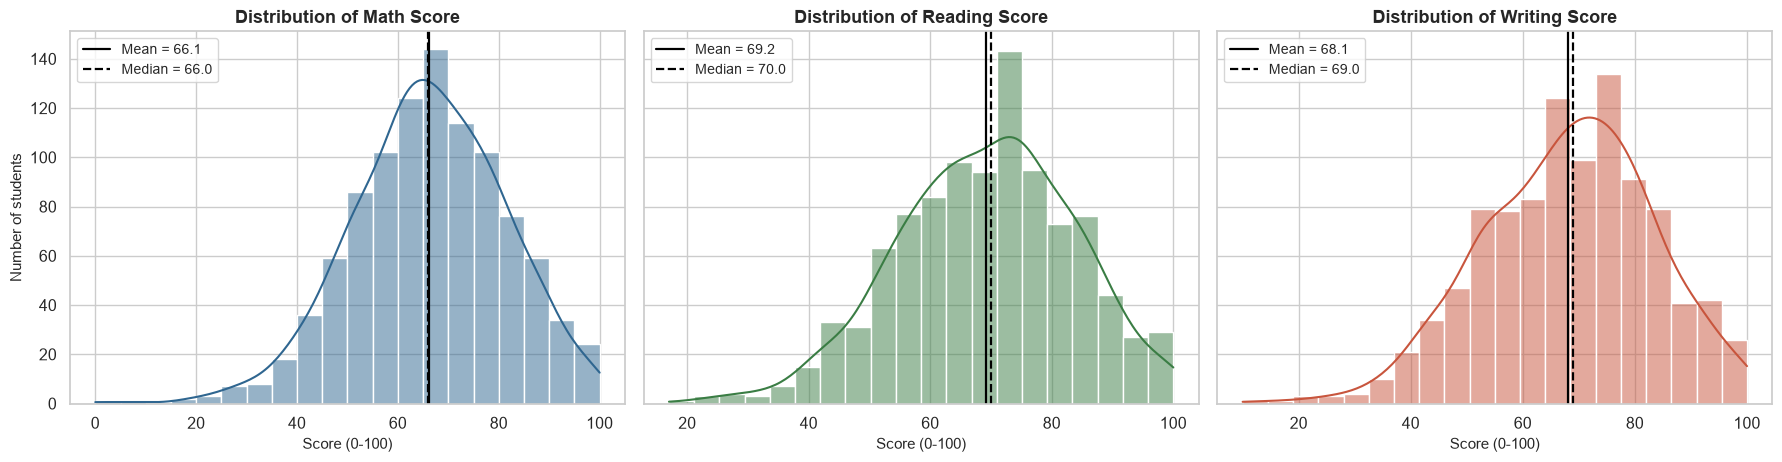

In [24]:
da.plot_histograms(df, SCORES, save_path=IMAGES_DIR / "histogram.png")

### Observation
All three histograms are **single-peaked and roughly bell-shaped**, with most students between about
55 and 80 points. The mean (solid line) and median (dashed line) are close together in every
subject, which fits a fairly symmetric distribution. The left tail is a little longer than the right
tail: there are a few students with very low scores (below about 30) but no matching group far
above the centre - high scores simply stop at the maximum of 100. There is also a visible bunching
of students at the top of the scale, especially in reading and writing, where a number of students
reach the maximum score of 100 (17 in reading, 14 in writing and 7 in math).

### 8.2 Categorical variables

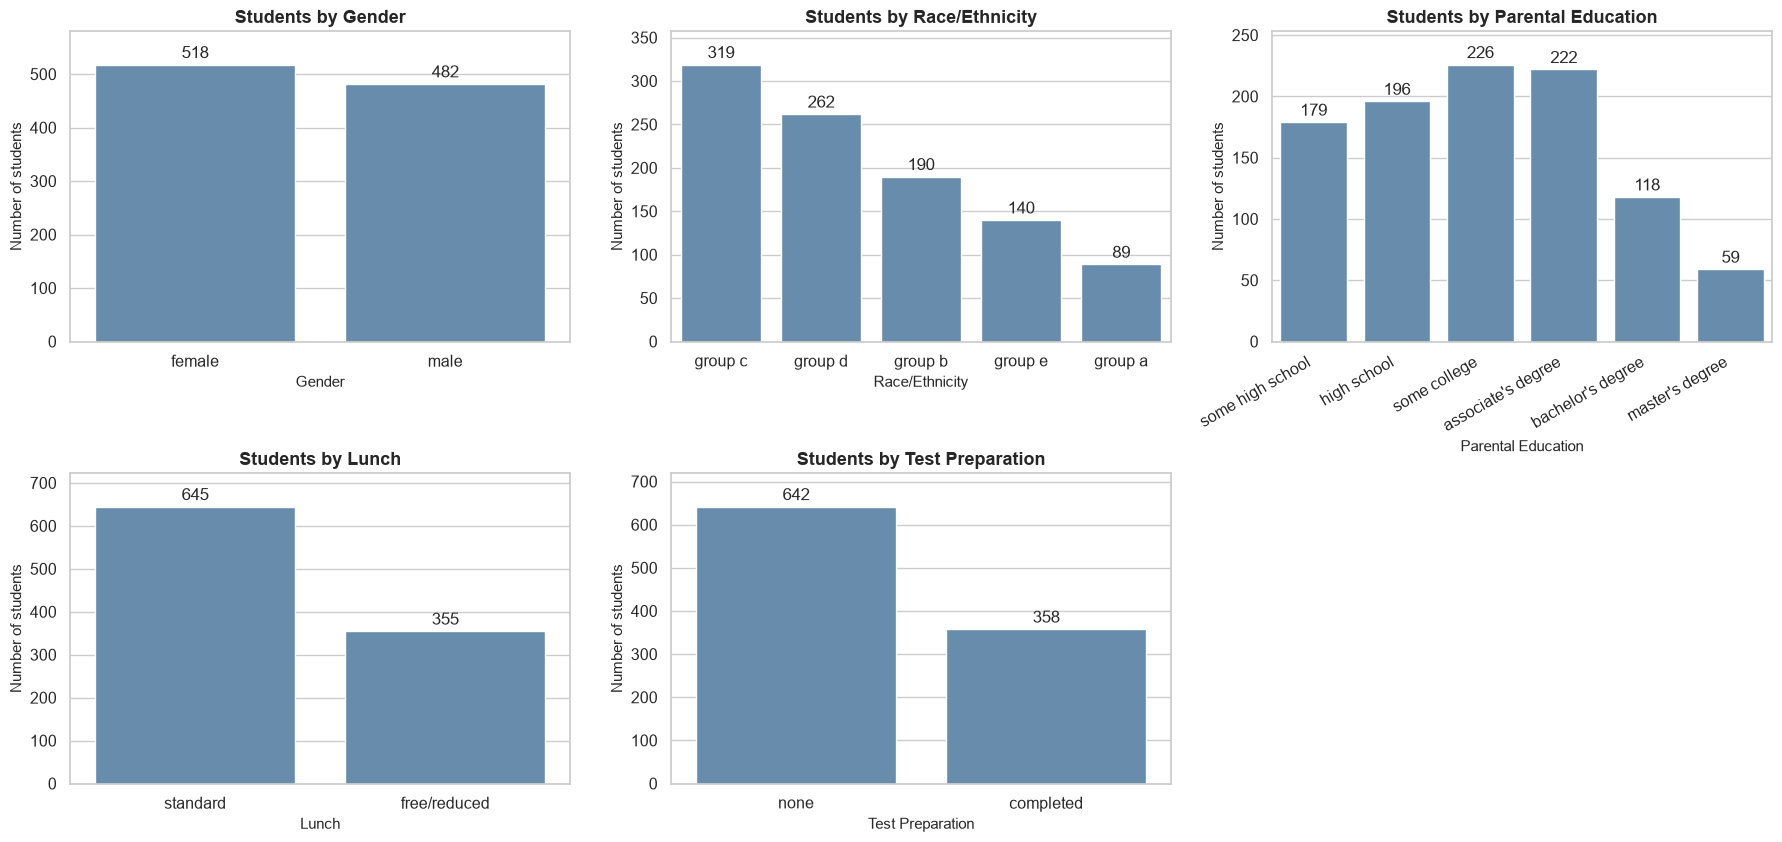

In [25]:
da.plot_countplots(df, categorical_cols, save_path=IMAGES_DIR / "categorical_counts.png")

### Observation
* **Gender** is almost balanced (518 female, 482 male).
* **Race/ethnicity** is uneven: group C is the largest (319 students) and group A the smallest (89).
* **Parental education** is concentrated in the middle levels (*some college* 226, *associate's
  degree* 222, *high school* 196, *some high school* 179). Only 118 students have a parent with a
  bachelor's degree and only 59 with a master's degree.
* **Lunch:** 645 students (64.5 %) have a standard lunch and 355 (35.5 %) a free/reduced lunch.
* **Test preparation:** 642 students (64.2 %) did not complete the preparation course and 358
  (35.8 %) did.

Several categories are small (for example group A and master's degree), so averages calculated for
those groups later are based on fewer students and are less stable.

## 9. Bivariate Analysis

Bivariate analysis studies the **relationship between two variables**. Scatter plots compare each pair
of exam scores; the line is a fitted straight line and `r` is the Pearson correlation coefficient
(explained in the next section).

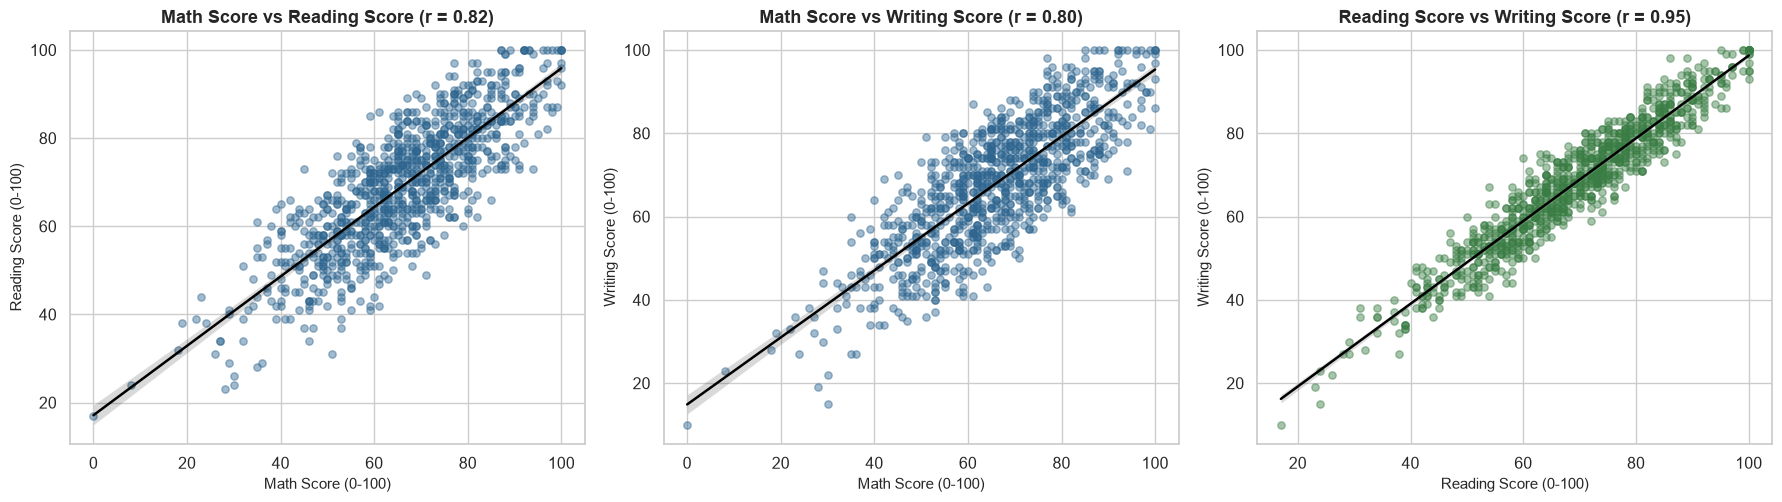

In [26]:
score_pairs = [("math_score", "reading_score"),
               ("math_score", "writing_score"),
               ("reading_score", "writing_score")]
da.plot_scatter_pairs(df, score_pairs, save_path=IMAGES_DIR / "scatter_plot.png")

### Observation
* In all three plots the points rise from the lower left to the upper right: **students who score
  higher in one subject tend to score higher in the others**.
* **Reading vs writing (r = 0.95)** shows the tightest relationship - the points sit very close to
  the fitted line.
* **Math vs reading (r = 0.82)** and **math vs writing (r = 0.80)** are also strong but more
  spread out: students with the same math score can differ by 20 or more points in reading or writing.
* The single point at the far lower left of the two math plots is a student with a math score of 0.
  This student also has the lowest reading and writing scores in the dataset (17 and 10), so the
  point lies on the same trend rather than being isolated from it (see the outlier analysis).
* The relationship is described well by a straight line; there is no sign of a curved pattern.

## 10. Correlation Analysis

The **Pearson correlation coefficient (r)** measures the strength and direction of a *linear*
relationship between two numerical variables: +1 means a perfect positive relationship, 0 means no
linear relationship and -1 means a perfect negative one. Only the numerical columns (the three scores)
can be used.

In [27]:
corr = da.correlation_matrix(df, SCORES)
corr.round(3)

,math_score,reading_score,writing_score
math_score,1.000,0.818,0.803
reading_score,0.818,1.000,0.955
writing_score,0.803,0.955,1.000


In [28]:
# Every pair listed once, from strongest positive to strongest negative
da.ranked_correlations(corr)

,variable_1,variable_2,correlation
0,reading_score,writing_score,0.955
1,math_score,reading_score,0.818
2,math_score,writing_score,0.803


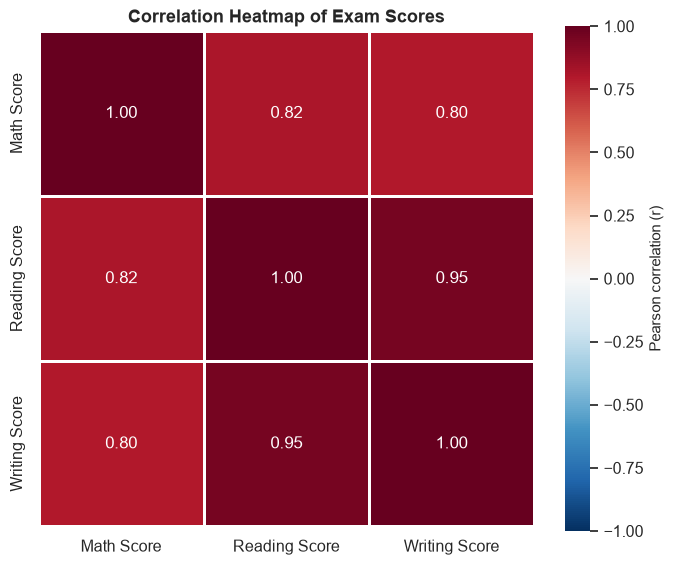

In [29]:
da.plot_correlation_heatmap(corr, save_path=IMAGES_DIR / "correlation_heatmap.png")

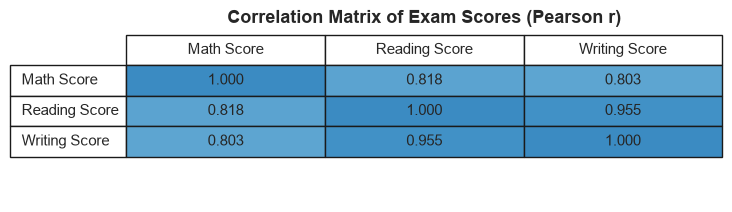

In [30]:
da.plot_correlation_table(corr, save_path=IMAGES_DIR / "correlation_matrix.png")

### Observation
* **Strongest positive relationship:** reading and writing (**r = 0.955**). Students who read well
  almost always write well too.
* **Next:** math and reading (**r = 0.818**) and math and writing (**r = 0.803**). Both are strong
  and positive, but clearly weaker than the reading-writing link, so math ability seems to be
  somewhat more separate from the two language-based scores.
* **Negative relationships:** none. All correlations are positive.
* **Weak relationships:** none among these three variables - even the lowest value (0.803) is a strong
  correlation. Weak or negative correlations cannot be studied here because the dataset has no other
  numerical variables.
* **Interpretation caution:** a high correlation shows that scores *move together*; it does not show
  that a good score in one subject *causes* a good score in another. A shared factor (for example
  general academic ability or the way the exams were set up) could explain the pattern. The
  heatmap and the matrix table above show the same numbers in two formats.

## 11. Outlier Analysis

A **potential statistical outlier** is a value that is unusually far from the rest of the data. The
**IQR rule** is used here: a value is flagged if it is below `Q1 - 1.5 x IQR` or above
`Q3 + 1.5 x IQR`, where `IQR = Q3 - Q1`. In a box plot, these values are drawn as individual circles
beyond the whiskers.

It is important to separate two ideas:

* **Potential statistical outlier** - unusual compared with the other students, but it may be a
  perfectly real value (for example a student who genuinely struggled).
* **Incorrect data** - impossible or clearly wrong (for example a score of 250 on a 0-100 scale).
  Only incorrect data should be corrected or removed.

In [31]:
outlier_summary = da.iqr_outlier_summary(df, SCORES)
outlier_summary

,column,lower_fence,upper_fence,n_outliers,percent_of_rows,lowest_value,highest_value
0,math_score,27.000,107.000,8,0.8,0,26
1,reading_score,29.000,109.000,6,0.6,17,28
2,writing_score,25.875,110.875,5,0.5,10,23


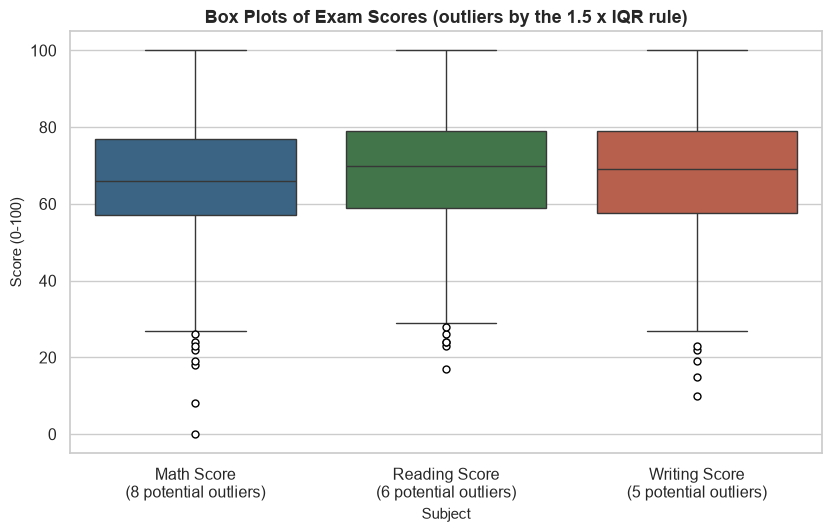

In [32]:
da.plot_boxplots(df, SCORES, save_path=IMAGES_DIR / "box_plot.png")

In [33]:
# Which students are flagged in at least one subject? (lowest average first)
flagged_index = sorted(set().union(*[set(da.get_outlier_rows(df, col).index) for col in SCORES]))
flagged = df.loc[flagged_index].copy()
flagged["average_score"] = flagged[SCORES].mean(axis=1).round(1)
flagged = flagged.sort_values("average_score")
display(flagged)

print("Students flagged in at least one subject:", len(flagged))
for col in ["lunch", "test_preparation", "gender"]:
    print(f"  {col}: {flagged[col].value_counts().to_dict()}")

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score,average_score
59,female,group c,some high school,free/reduced,none,0,17,10,9.0
980,female,group b,high school,free/reduced,none,8,24,23,18.3
596,male,group b,high school,free/reduced,none,30,24,15,23.0
327,male,group a,some college,free/reduced,none,28,23,19,23.3
76,male,group e,some high school,standard,none,30,26,22,26.0
17,female,group b,some high school,free/reduced,none,18,32,28,26.0
338,female,group b,some high school,free/reduced,none,24,38,27,29.7
787,female,group b,some college,standard,none,19,38,32,29.7
211,male,group c,some college,free/reduced,none,35,28,27,30.0
145,female,group c,some college,free/reduced,none,22,39,33,31.3


Students flagged in at least one subject: 12
  lunch: {'free/reduced': 10, 'standard': 2}
  test_preparation: {'none': 11, 'completed': 1}
  gender: {'female': 8, 'male': 4}


In [34]:
# Is any score impossible (incorrect data)?  And who has the score of 0?
print("Rows with a score outside 0-100:", len(dc.find_score_range_violations(df, SCORES)))
df[df["math_score"] == 0]

Rows with a score outside 0-100: 0


,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score
59,female,group c,some high school,free/reduced,none,0,17,10


### Observation
* **Box plots:** the box shows the middle 50 % of scores and the line inside it the median. Each
  subject has a compact box (about 57-79) and a long lower whisker. Circles appear only **below**
  the lower whisker.
* **Number of potential outliers:** **8 in math, 6 in reading and 5 in writing** (0.8 %, 0.6 % and
  0.5 % of students). In total **12 different students** are flagged in at least one subject, and
  several are flagged in more than one subject.
* **No high outliers:** the upper fences (107, 109 and about 111) lie above the maximum possible score
  of 100, so a score cannot exceed them. The high scores of 100 are the top of the scale, not outliers.
* **Are these values incorrect data?** No evidence of that: no score is outside the valid 0-100 range.
  The most extreme student (a math score of 0, reading 17, writing 10) is low in *all three*
  subjects, which is consistent with a student who really performed poorly rather than with a single
  typing mistake. A math score of 0 is a legitimate value on the scale, but it cannot be *proven*
  genuine from this dataset alone.
* **Pattern among the flagged students:** 10 of the 12 have a free/reduced lunch, and 11 of the 12
  did not complete the test-preparation course. This suggests the low-scoring group is not random,
  but it is only a description of 12 students, not an explanation.
* **Decision:** all potential outliers are **kept**. They are valid observations, they are few
  (12 of 1,000 students), and removing genuine low performers would make the data look better than
  it is. If they distort a future model, alternatives such as robust methods can be considered then.

## 12. Comparative Analysis

Now the scores are compared **across categories**. For convenience, an `average_score` column (the mean
of the three subject scores) is created **only for this EDA**; it is *not* saved to the cleaned
dataset, because it is just a combination of the existing columns.

### 12.1 Average scores by group (tables)

In [35]:
df_eda = df.copy()
df_eda["average_score"] = df_eda[SCORES].mean(axis=1)
COMPARE_COLS = SCORES + ["average_score"]

for col in categorical_cols:
    table = da.group_mean_table(df_eda, col, COMPARE_COLS)
    if col == "parental_education":                 # show education in its natural order
        table = table.reindex(da.EDUCATION_ORDER)
    print(f"--- Mean scores by {col} ---")
    display(table)

--- Mean scores by gender ---


,math_score,reading_score,writing_score,average_score,n_students
gender,,,,,
female,63.63,72.61,72.47,69.57,518
male,68.73,65.47,63.31,65.84,482


--- Mean scores by race_ethnicity ---


,math_score,reading_score,writing_score,average_score,n_students
race_ethnicity,,,,,
group a,61.63,64.67,62.67,62.99,89
group b,63.45,67.35,65.60,65.47,190
group c,64.46,69.10,67.83,67.13,319
group d,67.36,70.03,70.15,69.18,262
group e,73.82,73.03,71.41,72.75,140


--- Mean scores by parental_education ---


,math_score,reading_score,writing_score,average_score,n_students
parental_education,,,,,
some high school,63.50,66.94,64.89,65.11,179
high school,62.14,64.70,62.45,63.10,196
some college,67.13,69.46,68.84,68.48,226
associate's degree,67.88,70.93,69.90,69.57,222
bachelor's degree,69.39,73.00,73.38,71.92,118
master's degree,69.75,75.37,75.68,73.60,59


--- Mean scores by lunch ---


,math_score,reading_score,writing_score,average_score,n_students
lunch,,,,,
free/reduced,58.92,64.65,63.02,62.20,355
standard,70.03,71.65,70.82,70.84,645


--- Mean scores by test_preparation ---


,math_score,reading_score,writing_score,average_score,n_students
test_preparation,,,,,
completed,69.70,73.89,74.42,72.67,358
none,64.08,66.53,64.50,65.04,642


### 12.2 Distribution of the average score by group (box plots)

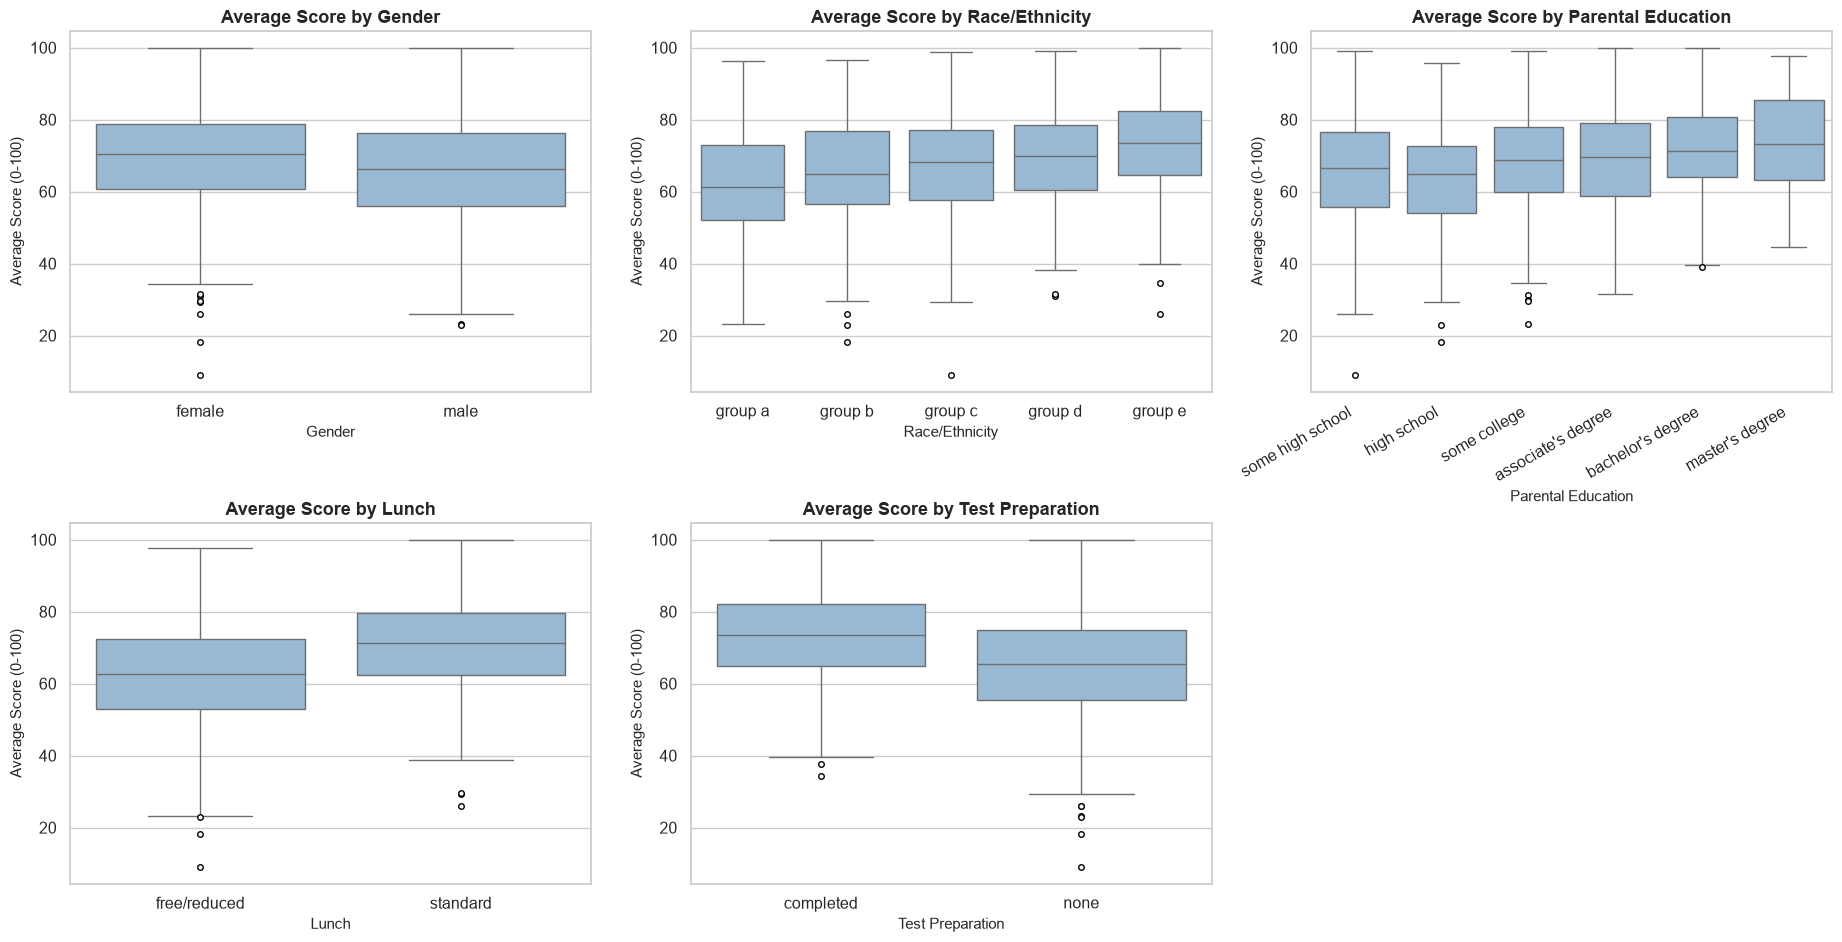

In [36]:
da.plot_group_boxplots(df_eda, categorical_cols, "average_score",
                       save_path=IMAGES_DIR / "score_by_category_boxplots.png")

### 12.3 Subject-level comparison: gender and parental education

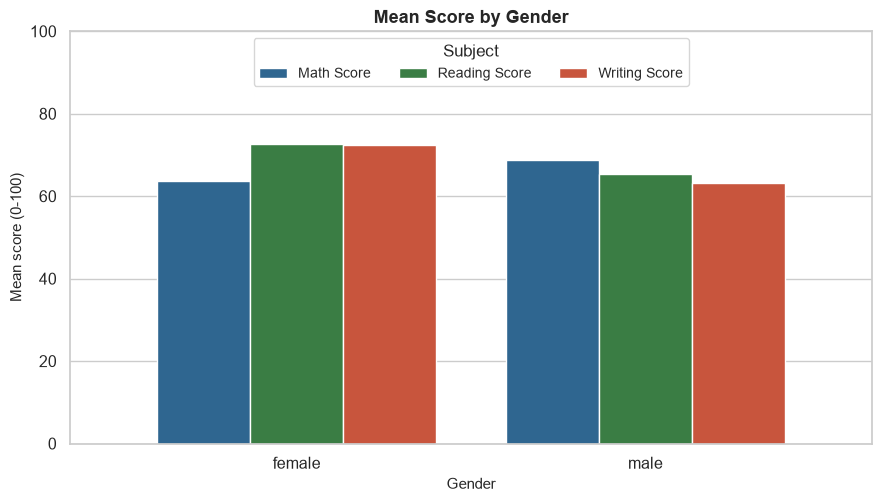

In [37]:
da.plot_grouped_means(df_eda, "gender", SCORES, save_path=IMAGES_DIR / "mean_scores_by_gender.png")

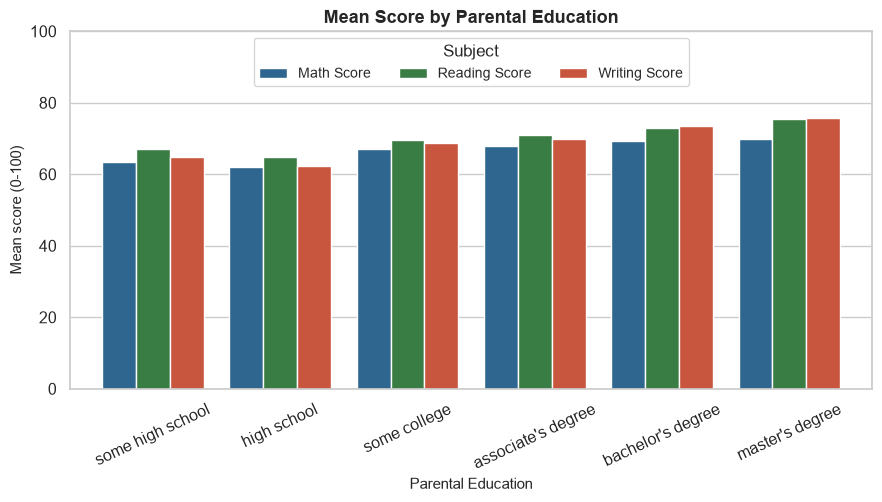

In [38]:
da.plot_grouped_means(df_eda, "parental_education", SCORES,
                      save_path=IMAGES_DIR / "mean_scores_by_parental_education.png")

### 12.4 Lunch type and test preparation together
Do the lunch and test-preparation differences simply reflect the same students? Two checks: the
share of students who completed the course in each lunch group, and the mean average score for every
combination.

In [39]:
print("Share of students who completed the test preparation course, by lunch type:")
display((pd.crosstab(df_eda["lunch"], df_eda["test_preparation"], normalize="index") * 100).round(1))

print("Mean average score by lunch type and test preparation:")
display(df_eda.pivot_table(index="lunch", columns="test_preparation", values="average_score").round(2))

Share of students who completed the test preparation course, by lunch type:


test_preparation,completed,none
lunch,,
free/reduced,36.9,63.1
standard,35.2,64.8


Mean average score by lunch type and test preparation:


test_preparation,completed,none
lunch,,
free/reduced,67.76,58.95
standard,75.51,68.30


### Observation
* **Test preparation:** students who **completed** the course average **72.67** versus **65.04** for
  those who did not - about **7.6 points higher**. The gap appears in every subject and is largest in
  writing (74.42 vs 64.50, about 9.9 points).
* **Lunch type:** students with a **standard lunch** average **70.84** versus **62.20** for free/reduced
  lunch - about **8.6 points higher**, the largest gap among the two-category variables. It is biggest
  in math (70.03 vs 58.92, about 11.1 points).
* **Gender:** the pattern depends on the subject. Male students score higher in **math** (68.73 vs
  63.63), while female students score higher in **reading** (72.61 vs 65.47) and **writing**
  (72.47 vs 63.31). Overall, the female average is about 3.7 points higher (69.57 vs 65.84).
* **Parental education:** the average score generally rises with the parent's education, from
  63.10 (*high school*) to 73.60 (*master's degree*). It is not perfectly ordered: *some high
  school* (65.11) is slightly above *high school* (63.10).
* **Race/ethnicity:** the group averages increase steadily from group A (62.99) to group E (72.75),
  but the groups are anonymized, differ greatly in size (89 to 319 students) and are likely to
  overlap with the other factors, so this is a description of the dataset, not an explanation.
* **Lunch and test preparation together:** the share of students who completed the course is
  almost the same in both lunch groups (36.9 % of free/reduced vs 35.2 % of standard), so the
  test-preparation gap is *not* just the lunch gap seen from another side. Both gaps appear inside
  every combination: e.g. free/reduced students who completed the course (67.76) score about
  the same as standard-lunch students who did not (68.30).
* **Box plots:** the boxes overlap considerably, so the group differences are *averages*: many
  students in the "lower" groups still score higher than many students in the "higher" groups.

## 13. Key Insights

Each insight below is based on the tables and charts produced in this notebook.

1. **The data is high quality.** All 1,000 records are complete: no missing values, no duplicate
   rows and no score outside the valid 0-100 range. Cleaning therefore changed the *format* (column
   names, text case) but not the number of rows.
2. **Scores are centered in the upper 60s and are slightly left-skewed.** Mean scores are 66.09
   (math), 69.17 (reading) and 68.05 (writing), with medians of 66, 70 and 69 and skewness of about -0.28,
   -0.26 and -0.29 (a longer tail of low scores).
3. **Math is the weakest subject on average.** Its mean is about 3 points below reading and about 2
   points below writing, and it is the only subject in which a student scored 0.
4. **Reading and writing scores move almost together.** Their correlation is 0.955, compared with 0.818
   (math-reading) and 0.803 (math-writing). All correlations are positive; none is weak or negative.
5. **All potential outliers are low scores.** The IQR rule flags 8 math, 6 reading and 5 writing scores
   (12 different students). No high outliers exist, because the upper fences are above the maximum
   possible score of 100.
6. **The outliers look like genuine low performance, not data errors.** No value is outside 0-100, and
   the most extreme student (math 0, reading 17, writing 10) is low in every subject. They were kept.
7. **Test preparation is associated with higher scores in every subject.** Students who completed the
   course average 72.67 vs 65.04 (about 7.6 points), with the largest gap in writing (about 9.9).
8. **Lunch type shows the biggest gap between two groups.** Standard-lunch students average 70.84 vs
   62.20 for free/reduced lunch (about 8.6 points), and the gap is largest in math (about 11.1). 10 of
   the 12 flagged low-score outliers have a free/reduced lunch.
9. **Gender differences depend on the subject.** Males average about 5.1 points higher in math;
   females average about 7.1 points higher in reading and 9.2 points higher in writing.
10. **Parental education is linked to a general upward trend in scores.** Averages range from 63.10
    (*high school*) to 73.60 (*master's degree*), although the order is not perfectly consistent.
11. **The lunch and test-preparation gaps hold within each other's groups.** Course completion is
    similarly common in both lunch groups (36.9 % vs 35.2 %), and each gap remains inside every
    combination of the other variable.
12. **Some categories are small.** Group A (89 students) and master's degree (59 students) make up
    few records, so their averages are less reliable than those of larger groups.

> All differences above are **associations within this dataset**. They do not prove cause and effect,
> and because the dataset's collection method is not documented, they should not be generalized
> to real student populations.

## 14. Preparing for Task 2

This section serves as a direct bridge from **Task 1** (Exploratory Data Analysis) to **Task 2** (Supervised Machine Learning).
Because Task 1 is strictly an exploration project, **no machine-learning models are trained here**.
Instead, this section outlines candidate prediction targets, analyzes class balance across potential
classification thresholds, documents the available predictor features, and highlights critical data
hygiene considerations such as preventing target leakage.

### Candidate prediction targets
The dataset contains individual subject marks (`math_score`, `reading_score`, `writing_score`) but **no single
designated 'final score' column**. In Task 2, a specific prediction target must therefore be chosen:

1. **Regression on `math_score`:** Predicting continuous performance on the math exam (0–100 scale) directly from
   student background characteristics.
2. **Regression on `average_score`:** Predicting overall academic achievement, defined as the unweighted arithmetic mean
   of the three subjects:
   $$\text{average\_score} = \frac{\text{math\_score} + \text{reading\_score} + \text{writing\_score}}{3}$$
3. **Classification of `average_score` $\ge$ a threshold:** Defining a binary classification problem (e.g. Pass vs Fail,
   or Meeting Benchmark vs Below Benchmark) based on whether a student meets or exceeds an established cutoff.

### Class balance for possible classification thresholds
When formulating a classification task, class balance determines whether standard evaluation metrics
(e.g., accuracy) are reliable or if specialized metrics (precision, recall, F1, ROC-AUC) and resampling techniques
are necessary. We compute from the real dataset the share of students with `average_score` $\ge$ 50, $\ge$ 60, $\ge$ 70,
and $\ge$ the sample median.

,Threshold,Cutoff Score,Count (>=,Share (>=\) (%),Count (<,Share (<\) (%),Class Ratio (>=\ : <)
0,>= 50,50.00,897,89.7,103,10.3,89.7 : 10.3
1,>= 60,60.00,715,71.5,285,28.5,71.5 : 28.5
2,>= 70,70.00,459,45.9,541,54.1,45.9 : 54.1
3,>= 68.33 (median),68.33,511,51.1,489,48.9,51.1 : 48.9


Saved: D:\internship_summer\Task1\images\threshold_balance.png


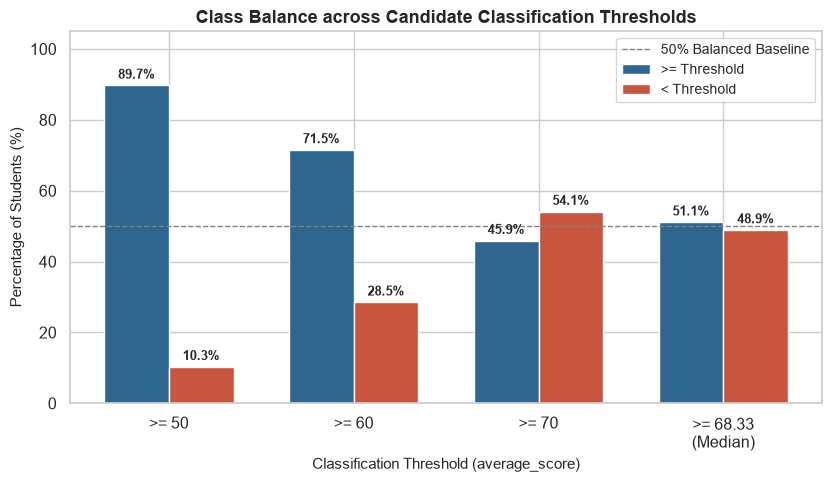

In [40]:
# Compute class balance across candidate classification thresholds from the real data
score_columns = ["math_score", "reading_score", "writing_score"]
avg_scores = df[score_columns].mean(axis=1)
median_cutoff = avg_scores.median()

threshold_candidates = [
    (">= 50", 50.0),
    (">= 60", 60.0),
    (">= 70", 70.0),
    (f">= {median_cutoff:.2f} (median)", median_cutoff),
]

balance_rows = []
for label, cutoff in threshold_candidates:
    n_ge = int((avg_scores >= cutoff).sum())
    pct_ge = round((n_ge / len(df)) * 100, 1)
    n_lt = int((avg_scores < cutoff).sum())
    pct_lt = round((n_lt / len(df)) * 100, 1)
    balance_rows.append({
        "Threshold": label,
        "Cutoff Score": round(cutoff, 2),
        "Count (>=": n_ge,
        "Share (>=\) (%)": pct_ge,
        "Count (<": n_lt,
        "Share (<\) (%)": pct_lt,
        "Class Ratio (>=\ : <)": f"{pct_ge:.1f} : {pct_lt:.1f}",
    })

balance_df = pd.DataFrame(balance_rows)
display(balance_df)

# Plot class balance and save image
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(threshold_candidates))
width = 0.35

chart_labels = [">= 50", ">= 60", ">= 70", f">= {median_cutoff:.2f}\n(Median)"]
pct_pass = [r["Share (>=\) (%)"] for r in balance_rows]
pct_fail = [r["Share (<\) (%)"] for r in balance_rows]

rects1 = ax.bar(x - width/2, pct_pass, width, label=">= Threshold", color="#2F6690", edgecolor="white")
rects2 = ax.bar(x + width/2, pct_fail, width, label="< Threshold", color="#C8553D", edgecolor="white")

ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% Balanced Baseline")
ax.set_title("Class Balance across Candidate Classification Thresholds")
ax.set_xlabel("Classification Threshold (average_score)")
ax.set_ylabel("Percentage of Students (%)")
ax.set_xticks(x)
ax.set_xticklabels(chart_labels)
ax.set_ylim(0, 105)
ax.legend(loc="upper right")

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
save_img_path = IMAGES_DIR / "threshold_balance.png"
plt.savefig(save_img_path, dpi=150, bbox_inches="tight")
print("Saved:", save_img_path)
plt.show()


### Observation on class balance
Using only the computed numbers from the dataset:
* **Threshold $\ge$ 50:** **Badly imbalanced** (89.7% meeting the threshold vs 10.3% below; 897 vs 103 students).
  A trivial majority classifier predicting pass for every student would achieve 89.7% accuracy while failing to
  detect struggling students. Accuracy is therefore misleading for this threshold.
* **Threshold $\ge$ 60:** **Moderately imbalanced** (71.5% meeting the threshold vs 28.5% below; 715 vs 285 students;
  approximately a 2.5:1 ratio).
* **Threshold $\ge$ 70:** **Close to balanced** (45.9% meeting the threshold vs 54.1% below; 459 vs 541 students;
  approximately a 0.85:1 ratio). This yields a realistic, naturally balanced target.
* **Threshold $\ge$ median (68.33):** **Nearly perfectly balanced** (51.1% meeting the threshold vs 48.9% below;
  511 vs 489 students). Splitting at the sample median provides the most balanced binary classification target possible.

### Data leakage warning

> **CRITICAL FOR TASK 2:** If the prediction target is derived from `math_score`, `reading_score`, or `writing_score`
> (such as `average_score` or an `average_score >= threshold` indicator), **none of those score columns (and nothing
> computed from them) may be used as input features**.

**Why?**
`average_score` is the arithmetic mean of math, reading, and writing scores. If any of those score columns were included
in the feature matrix $X$, the model would be given direct information about the target it is trying to predict.
In a real-world educational setting, the goal of a predictive model is to identify students who need support *before*
they sit for exams, when test scores do not yet exist. Including test scores in the input features constitutes
**target leakage** (data leakage). It would produce artificially high evaluation metrics during training (e.g. $R^2 \approx 1.0$
or near-100% accuracy) that would completely fail on unseen real-world data where exam scores are unavailable.

Supervised models in Task 2 must strictly predict outcomes using only student background features available before exams.

### Features available for Task 2

Excluding the score columns leaves exactly 5 background features for modeling:

| Feature | Type | Number of Categories | Unique Categories | Ordered? |
|---|---|---|---|---|
| `gender` | Categorical | 2 | `female`, `male` | No (nominal binary) |
| `race_ethnicity` | Categorical | 5 | `group a`, `group b`, `group c`, `group d`, `group e` | No (nominal groups) |
| `parental_education` | Categorical | 6 | `some high school`, `high school`, `some college`, `associate's degree`, `bachelor's degree`, `master's degree` | **Yes (ordered)**: `some high school` < `high school` < `some college` < `associate's degree` < `bachelor's degree` < `master's degree` |
| `lunch` | Categorical | 2 | `free/reduced`, `standard` | No (nominal binary) |
| `test_preparation` | Categorical | 2 | `completed`, `none` | No (nominal binary) |

In Task 2, nominal variables (`gender`, `race_ethnicity`, `lunch`, `test_preparation`) can be one-hot encoded or binary-encoded,
while `parental_education` can be ordinally encoded (e.g., 0 to 5) to reflect its natural hierarchy.

### Honest note on missing features
* **No behavioral, temporal, or attendance columns exist:** The dataset contains **no age, study-time, homework, or attendance column**.
* Such features cannot be created or imputed because the information was never recorded.
* Any supervised model in Task 2 must rely solely on the 5 background attributes above. As shown in Section 12, there is
  considerable overlap between groups, so predictive models based solely on these 5 features will have modest explanatory power.
  This is an honest limitation of the dataset, not a flaw in the modeling methodology.

## 15. Conclusion

**What was analyzed.** A dataset of 1,000 students with three exam scores (math, reading, writing)
and five background variables was loaded, inspected, checked for quality, cleaned, summarized and
visualized.

**Data quality.** The data was complete and free of duplicates and invalid scores. Cleaning
standardized the column names and text values and produced `data/cleaned_student_data.csv`
(1,000 rows x 8 columns).

**Important patterns.** Scores are roughly bell-shaped with a slightly longer low-score tail; the
three subject scores are strongly and positively correlated (reading-writing 0.955 is the strongest);
the only outliers are a small number (12) of unusually low scores that look genuine; and average
scores differ between groups - most clearly for lunch type (about 8.6 points), test preparation (about
7.6 points), gender (subject-dependent) and parental education.

**Limitations.** Only three numerical variables exist, so correlation analysis is limited; some
categories are small; group differences are descriptive, not causal; and the way the data was collected
is not documented.

**Use in future tasks.** The cleaned dataset is ready to be reused. **Task 2** can use it for machine
learning preprocessing and model development - for example encoding the categorical columns,
scaling numerical features, splitting into training and test sets and evaluating models. Those steps
were intentionally **not** performed here, because Task 1 is limited to data exploration.